In [44]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [7]:
conn = sqlite3.connect('sales.db')
df.to_sql('sales', conn, if_exists='replace', index=False)
print("Database created! Rows loaded:", len(df))

Database created! Rows loaded: 9994


In [8]:
def run_query(query):
    return pd.read_sql_query(query,conn)

In [9]:
query = """
SELECT
    round(sum(sales),2) AS total_sales,
    round(sum(profit),2) AS total_profit,
    count(*) AS total_orders
FROM sales
"""

run_query(query)

,total_sales,total_profit,total_orders
0,2297200.86,286397.02,9994


In [10]:
query ="""
SELECT 
    Region,
    round(sum(sales),2)as total_sales,
    round(sum(profit),2)as total_profit
from sales
group by region 
order by total_sales DESC
"""
run_query(query)

,Region,total_sales,total_profit
0,West,725457.82,108418.45
1,East,678781.24,91522.78
2,Central,501239.89,39706.36
3,South,391721.91,46749.43


In [11]:
query= """
SELECT 
    "Product Name",
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM sales
GROUP BY "Product Name"
ORDER BY total_sales DESC
LIMIT 10
"""
run_query(query)


,Product Name,total_sales,total_profit
0,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08
3,HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00
4,GBC DocuBind TL300 Electric Binding System,19823.48,2233.51
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98
6,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90,4094.98
8,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17
9,High Speed Automatic Electric Letter Opener,17030.31,-262.00


In [12]:
query = """
select 
    category,
    "Sub-Category",
    round(sum(sales),2) as total_sales,
    round(sum(profit),2) as total_profit
from sales
group by category,"Sub-Category"
order by total_sales desc
"""

run_query(query)

,Category,Sub-Category,total_sales,total_profit
0,Technology,Phones,330007.05,44515.73
1,Furniture,Chairs,328449.10,26590.17
2,Office Supplies,Storage,223843.61,21278.83
3,Furniture,Tables,206965.53,-17725.48
4,Office Supplies,Binders,203412.73,30221.76
5,Technology,Machines,189238.63,3384.76
6,Technology,Accessories,167380.32,41936.64
7,Technology,Copiers,149528.03,55617.82
8,Furniture,Bookcases,114880.00,-3472.56
9,Office Supplies,Appliances,107532.16,18138.01


In [15]:
query = """
SELECT 
    SUBSTR("Order Date", 1, 7) AS month,
    ROUND(SUM(Sales), 2) AS monthly_sales
FROM sales
GROUP BY month
ORDER BY month
"""
run_query(query)

,month,monthly_sales
0,1/1/201,1481.83
1,1/10/20,1247.68
2,1/11/20,159.38
3,1/12/20,1703.13
4,1/13/20,8795.40
...,...,...
361,9/5/201,6783.80
362,9/6/201,2419.55
363,9/7/201,10295.11
364,9/8/201,20996.38


In [16]:
df_region = run_query("""
    SELECT Region,
        ROUND(SUM(Sales), 2) AS total_sales,
        ROUND(SUM(Profit), 2) AS total_profit
    FROM sales
    GROUP BY Region
    ORDER BY total_sales DESC
""")

df_category = run_query("""
    SELECT Category, "Sub-Category",
        ROUND(SUM(Sales), 2) AS total_sales,
        ROUND(SUM(Profit), 2) AS total_profit
    FROM sales
    GROUP BY Category, "Sub-Category"
    ORDER BY total_sales DESC
""")

df_monthly = run_query("""
    SELECT SUBSTR("Order Date", 1, 7) AS month,
        ROUND(SUM(Sales), 2) AS monthly_sales
    FROM sales
    GROUP BY month
    ORDER BY month
""")

df_region

,Region,total_sales,total_profit
0,West,725457.82,108418.45
1,East,678781.24,91522.78
2,Central,501239.89,39706.36
3,South,391721.91,46749.43


In [17]:
df.shape 

(9994, 21)

In [18]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [19]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [21]:
df['profit_margin'] = (df['Profit'] / df['Sales']) * 100
df['profit_margin'] = df['profit_margin'].round(2)

df[['Product Name', 'Sales', 'Profit', 'profit_margin']].head(10)

,Product Name,Sales,Profit,profit_margin
0,Bush Somerset Collection Bookcase,261.9600,41.9136,16.00
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,219.5820,30.00
2,Self-Adhesive Address Labels for Typewriters b...,14.6200,6.8714,47.00
3,Bretford CR4500 Series Slim Rectangular Table,957.5775,-383.0310,-40.00
4,Eldon Fold 'N Roll Cart System,22.3680,2.5164,11.25
5,Eldon Expressions Wood and Plastic Desk Access...,48.8600,14.1694,29.00
6,Newell 322,7.2800,1.9656,27.00
7,Mitel 5320 IP Phone VoIP phone,907.1520,90.7152,10.00
8,DXL Angle-View Binders with Locking Rings by S...,18.5040,5.7825,31.25
9,Belkin F5C206VTEL 6 Outlet Surge,114.9000,34.4700,30.00


In [22]:
losing = df[df['Profit'] < 0]
print("Number of loss-making orders:", len(losing))

losing[['Product Name', 'Category', 'Sales', 'Profit']]\
    .sort_values('Profit')\
    .head(10)

Number of loss-making orders: 1871


,Product Name,Category,Sales,Profit
7772,Cubify CubeX 3D Printer Double Head Print,Technology,4499.985,-6599.9780
683,Cubify CubeX 3D Printer Triple Head Print,Technology,7999.980,-3839.9904
9774,GBC DocuBind P400 Electric Binding System,Office Supplies,2177.584,-3701.8928
3011,Lexmark MX611dhe Monochrome Laser Printer,Technology,2549.985,-3399.9800
4991,Ibico EPK-21 Electric Binding System,Office Supplies,1889.990,-2929.4845
3151,Cubify CubeX 3D Printer Double Head Print,Technology,1799.994,-2639.9912
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,1525.188,-2287.7820
9639,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4297.644,-1862.3124
1199,GBC DocuBind P400 Electric Binding System,Office Supplies,1088.792,-1850.9464
2697,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1811.0784


In [23]:
df_discount = df.groupby('Discount').agg(
    avg_profit=('Profit', 'mean'),
    total_orders=('Profit', 'count')
).round(2).reset_index()

df_discount

,Discount,avg_profit,total_orders
0,0.00,66.90,4798
1,0.10,96.06,94
2,0.15,27.29,52
3,0.20,24.70,3657
4,0.30,-45.68,227
5,0.32,-88.56,27
6,0.40,-111.93,206
7,0.45,-226.65,11
8,0.50,-310.70,66
9,0.60,-43.08,138


In [24]:
df_monthly

,month,monthly_sales
0,1/1/201,1481.83
1,1/10/20,1247.68
2,1/11/20,159.38
3,1/12/20,1703.13
4,1/13/20,8795.40
...,...,...
361,9/5/201,6783.80
362,9/6/201,2419.55
363,9/7/201,10295.11
364,9/8/201,20996.38


In [25]:
df_category

,Category,Sub-Category,total_sales,total_profit
0,Technology,Phones,330007.05,44515.73
1,Furniture,Chairs,328449.10,26590.17
2,Office Supplies,Storage,223843.61,21278.83
3,Furniture,Tables,206965.53,-17725.48
4,Office Supplies,Binders,203412.73,30221.76
5,Technology,Machines,189238.63,3384.76
6,Technology,Accessories,167380.32,41936.64
7,Technology,Copiers,149528.03,55617.82
8,Furniture,Bookcases,114880.00,-3472.56
9,Office Supplies,Appliances,107532.16,18138.01


In [26]:
df[['Product Name', 'Sales', 'Profit', 'profit_margin']].describe()

,Sales,Profit,profit_margin
count,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,12.031390
std,623.245101,234.260108,46.675436
min,0.444000,-6599.978000,-275.000000
25%,17.280000,1.728750,7.500000
50%,54.490000,8.666500,27.000000
75%,209.940000,29.364000,36.250000
max,22638.480000,8399.976000,50.000000


In [27]:
df.groupby("Region")[["Sales","Profit"]].agg(["mean","median","std"]).round(2)

Sales                Profit               
           mean median     std   mean median     std
Region                                              
Central  215.77  45.98  632.78  17.09   5.18  291.49
East     238.34  54.90  620.71  32.14   8.17  251.61
South    241.80  54.59  774.80  28.86   9.07  212.89
West     226.49  60.84  524.88  33.85  11.17  174.11

In [29]:
df.groupby("Category")[["Sales","Profit"]].agg(["mean","median","std"]).round(2)

Sales                  Profit               
                   mean  median      std   mean median     std
Category                                                      
Furniture        349.83  182.22   503.18   8.70   7.77  136.05
Office Supplies  119.32   27.42   382.18  20.33   6.88  164.89
Technology       452.71  166.16  1108.66  78.75  25.02  428.82

In [30]:
df[['Sales', 'Profit', 'Discount', 'Quantity']].corr().round(2)

,Sales,Profit,Discount,Quantity
Sales,1.00,0.48,-0.03,0.20
Profit,0.48,1.00,-0.22,0.07
Discount,-0.03,-0.22,1.00,0.01
Quantity,0.20,0.07,0.01,1.00


In [32]:
mean_sales = df['Sales'].mean()
std_sales = df['Sales'].std()

upper = mean_sales + (3 * std_sales)
lower = mean_sales - (3 * std_sales)

outliers = df[(df['Sales'] > upper) | (df['Sales'] < lower)]
print("Number of outliers:", len(outliers))
print("Mean sales:", round(mean_sales, 2))
print("Std dev:", round(std_sales, 2))
print("Upper limit:", round(upper, 2))

outliers[['Product Name', 'Category', 'Sales', 'Profit']].head(10)

Number of outliers: 127
Mean sales: 229.86
Std dev: 623.25
Upper limit: 2099.59


,Product Name,Category,Sales,Profit
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,3083.4300,-1665.0522
165,Lexmark MX611dhe Monochrome Laser Printer,Technology,8159.9520,-1359.9920
251,Logitech P710e Mobile Speakerphone,Technology,3347.3700,636.0003
262,Lexmark MX611dhe Monochrome Laser Printer,Technology,3059.9820,-509.9970
263,Xerox WorkCentre 6505DN Laser Multifunction Pr...,Technology,2519.9580,-251.9958
318,Canon imageCLASS MF7460 Monochrome Digital Las...,Technology,3991.9800,1995.9900
353,GBC DocuBind P400 Electric Binding System,Office Supplies,4355.1680,1415.4296
399,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,2396.2656,-317.1528
487,Apple iPhone 5S,Technology,2735.9520,341.9940
509,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,6354.9500,3177.4750


In [40]:
df.groupby("Sub-Category")['Profit'].agg(
           total_profit = 'sum',
           avg_profit='mean',
           order_count='count'
           ).round(2).sort_values("total_profit",ascending=False).head(5)

,total_profit,avg_profit,order_count
Sub-Category,,,
Copiers,55617.82,817.91,68
Phones,44515.73,50.07,889
Accessories,41936.64,54.11,775
Paper,34053.57,24.86,1370
Binders,30221.76,19.84,1523


In [39]:
df.groupby('Sub-Category')['Profit'].agg(
    total_profit='sum',
    avg_profit='mean',
    order_count='count'
).round(2).sort_values('total_profit', ascending=True).head(5)

,total_profit,avg_profit,order_count
Sub-Category,,,
Tables,-17725.48,-55.57,319
Bookcases,-3472.56,-15.23,228
Supplies,-1189.10,-6.26,190
Fasteners,949.52,4.38,217
Machines,3384.76,29.43,115


In [41]:
df_discount_analysis = df.groupby("Discount")["Profit"].mean().round(2)
df_discount_analysis

Discount
0.00     66.90
0.10     96.06
0.15     27.29
0.20     24.70
0.30    -45.68
0.32    -88.56
0.40   -111.93
0.45   -226.65
0.50   -310.70
0.60    -43.08
0.70    -95.87
0.80   -101.80
Name: Profit, dtype: float64

C:\Users\chakr\AppData\Local\Temp\ipykernel_161024\3118638060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region, x='Region', y='total_sales', palette='Blues_d')


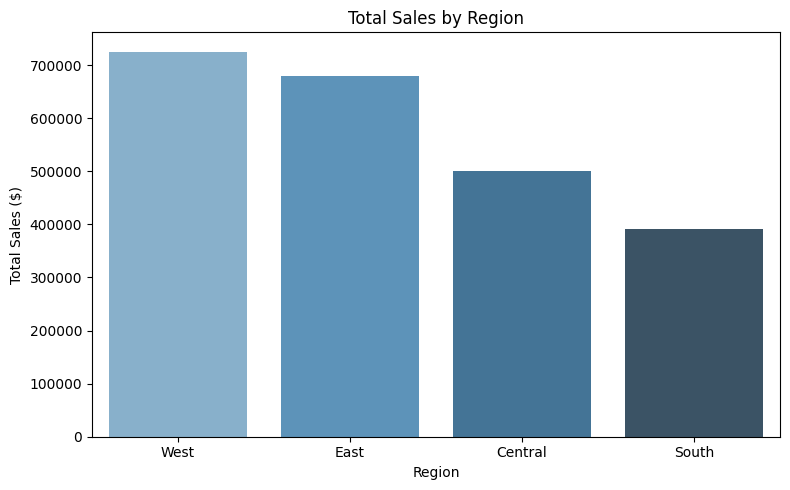

In [45]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_region, x='Region', y='total_sales', palette='Blues_d')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

C:\Users\chakr\AppData\Local\Temp\ipykernel_161024\3613872955.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region, x='Region', y='total_profit', palette='Greens_d')


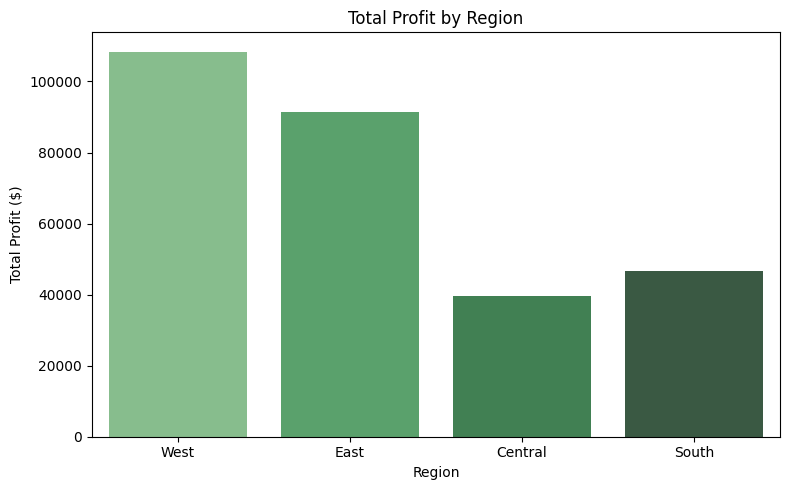

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_region, x='Region', y='total_profit', palette='Greens_d')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()

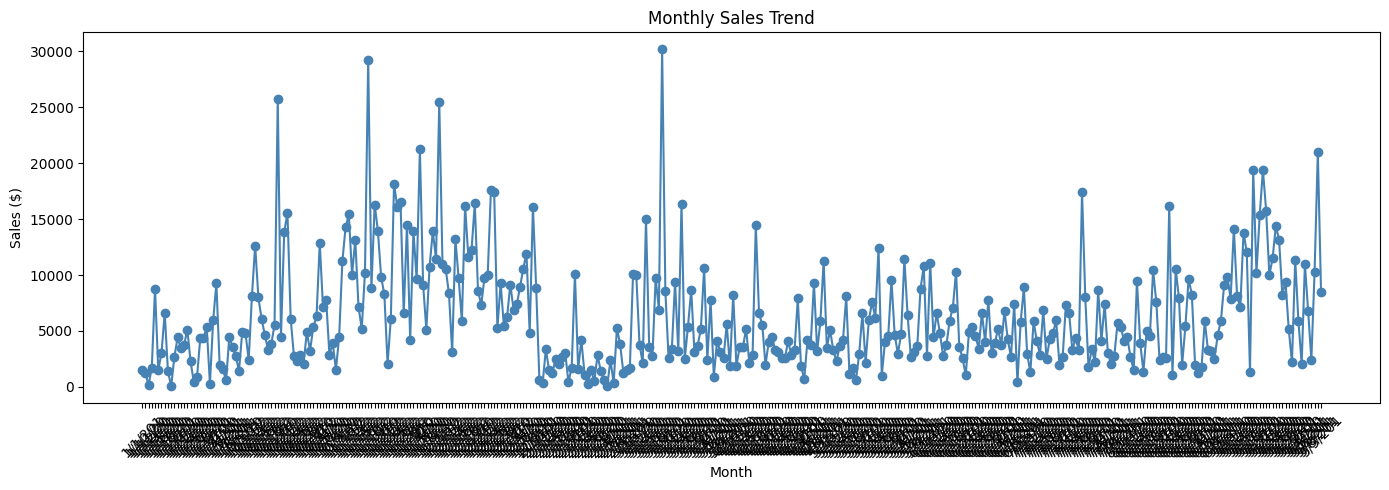

In [47]:
plt.figure(figsize=(14, 5))
plt.plot(df_monthly['month'], df_monthly['monthly_sales'], marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

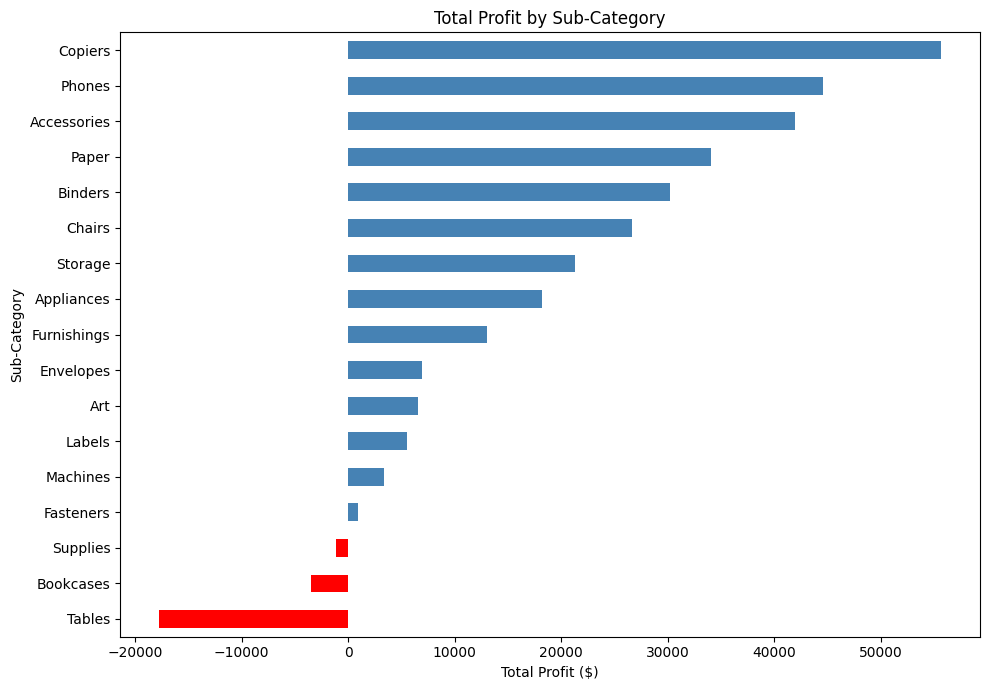

In [48]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().round(2).sort_values()

plt.figure(figsize=(10, 7))
colors = ['red' if x < 0 else 'steelblue' for x in sub_profit.values]
sub_profit.plot(kind='barh', color=colors)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

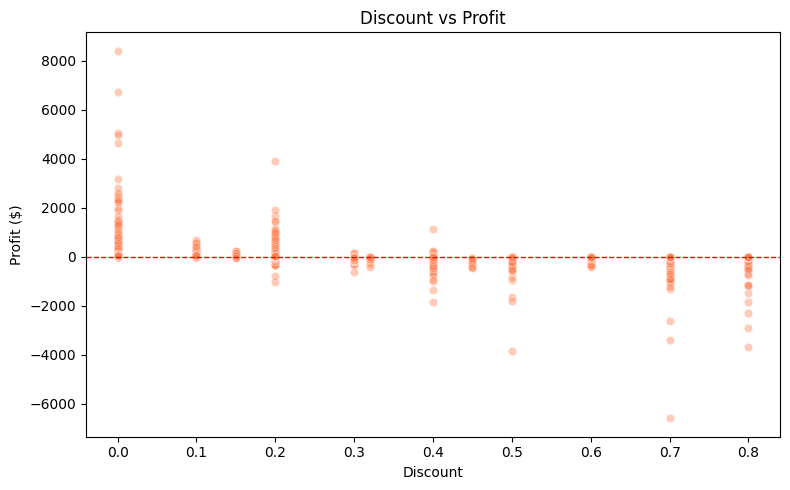

In [49]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, color='coral')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

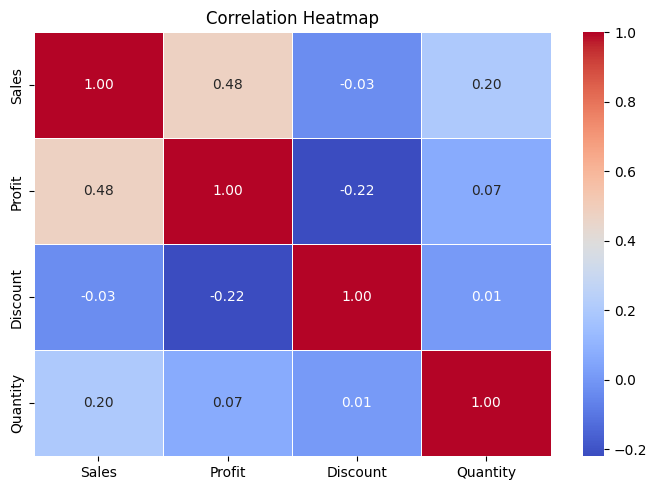

In [50]:
plt.figure(figsize=(7, 5))
corr = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

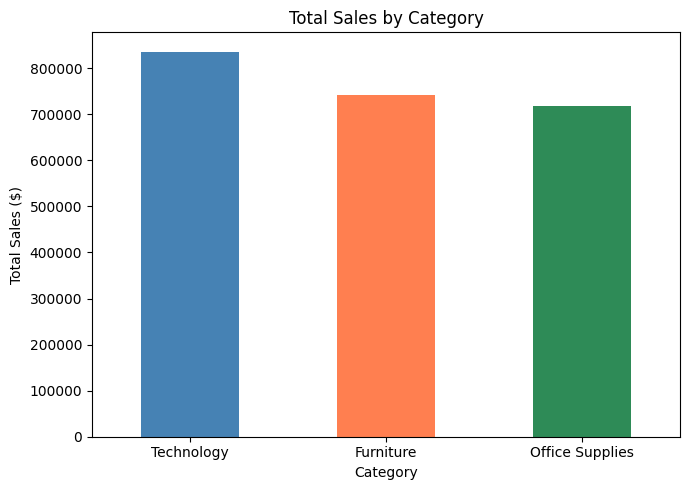

In [51]:
cat_sales = df.groupby('Category')['Sales'].sum().round(2).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
cat_sales.plot(kind='bar', color=['steelblue', 'coral', 'seagreen'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
next